loss: 0.07515045255422592 epoch: 0
loss: 0.0011943270219489932 epoch: 500
loss: 0.00014533281500916928 epoch: 1000
loss: 2.7831236366182566e-05 epoch: 1500
loss: 2.2638523660134524e-05 epoch: 2000
loss: 1.212025927088689e-05 epoch: 2500
loss: 4.639507824322209e-05 epoch: 3000
loss: 6.72434134685318e-06 epoch: 3500
loss: 4.4486245315056294e-05 epoch: 4000
loss: 4.054864803038072e-06 epoch: 4500
Mean abs Error: 0.000998
final loss: 0.000002


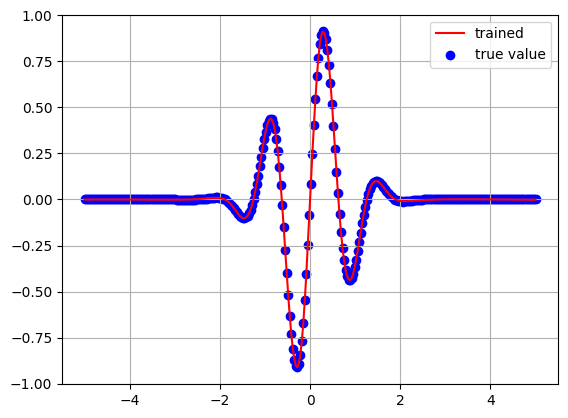

In [2]:
#Oscillatory decaying function:
#Imports
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#Data Generation
x=torch.linspace(-5,5,300).view(-1,1)
y=torch.exp(-x**2)*torch.sin(5*x)

#Model Architecture
class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.input=nn.Linear(1,32)
    self.l1=nn.Linear(32,32)
    self.l2=nn.Linear(32,32)
    self.output=nn.Linear(32,1)

  def forward(self,x):
    x=torch.tanh(self.input(x))
    x=torch.tanh(self.l1(x))
    x=torch.tanh(self.l2(x))
    x=self.output(x)

    return x

model=Net()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

#Training + Loss curve
for  epoch in range(5000):
  optimizer.zero_grad()
  ypred=model(x)
  loss=criterion(ypred,y)
  loss.backward()
  optimizer.step()

  if epoch%500==0:
    print('loss:',loss.item(),'epoch:',epoch)

#Evaluation

with torch.no_grad():
  pred=model(x)
  mae=torch.mean(torch.abs(pred-y)).mean()
  print(f"Mean abs Error: {mae.item():0.6f}")
  print(f'final loss: {loss.item():.6f}')


plt.plot(x.numpy(),pred.numpy(),label='trained',color='red')
plt.scatter(x.numpy(),y.numpy(),label='true value',color='blue')
plt.legend()
plt.grid(True)
plt.show()


Observations:

1. Oscillatory functions need depth, not just width
2. Depth creates a feature hierarchy — each layer builds on the last
3. High learning rate causes unstable loss
4. Sparse data at edges + small amplitude = hard to fit
5. The decay envelope and oscillations are two separate structures the network has to learn simultaneously